# Swing Path Exploratory Analysis

This notebook explores bat-tracking swing metrics and contact quality (Barrel%, HardHit%, etc.) for MLB players. Data spans 2023–2025.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

In [30]:
df = pd.read_csv('swing-path-with-stats.csv')
print(f"Loaded {len(df)} players")
df.head()

Loaded 188 players


,id,name,side,avg_bat_speed,swing_tilt,attack_angle,attack_direction,ideal_attack_angle_rate,avg_intercept_y_vs_plate,avg_intercept_y_vs_batter,...,maxEV,HardHit,HardHit%,Events,CStr%,CSW%,xBA,xSLG,xwOBA,L-WAR
0,519317,"Stanton, Giancarlo",R,80.986946,27.055286,9.123527,-2.495349,0.600775,0.825511,26.569680,...,120.0,357,0.526,679,0.183,0.325,0.230,0.502,0.343,1.8
1,665833,"Cruz, Oneil",L,78.654185,33.188333,8.758917,-7.008268,0.447788,8.332501,35.326219,...,122.9,380,0.550,691,0.181,0.322,0.239,0.450,0.334,5.1
2,656941,"Schwarber, Kyle",L,77.355463,29.819476,13.744417,-5.563785,0.656770,10.126857,32.347252,...,117.2,636,0.546,1165,0.182,0.301,0.239,0.532,0.382,10.0
3,666176,"Adell, Jo",R,77.311629,33.281562,6.641320,-5.070126,0.471963,0.215011,25.918602,...,117.2,327,0.471,695,0.129,0.270,0.239,0.486,0.337,1.9
4,592450,"Judge, Aaron",R,76.971213,39.584526,14.457912,-5.284475,0.513058,1.977635,30.469694,...,118.1,619,0.607,1019,0.151,0.284,0.298,0.726,0.469,27.1


## Correlations with Barrel%

How do swing path metrics correlate with contact quality?

In [31]:
swing_cols = ['avg_bat_speed', 'swing_tilt', 'attack_angle', 'attack_direction', 'ideal_attack_angle_rate']
cols = [c for c in swing_cols if c in df.columns]

corrs = df[cols + ['Barrel%']].corr()['Barrel%'].drop('Barrel%')
corrs = corrs.sort_values(key=abs, ascending=False)
print("Correlation with Barrel%:")
print(corrs.to_string())

Correlation with wRC+:
avg_bat_speed              0.320207
swing_tilt                 0.117621
attack_direction          -0.088534
attack_angle               0.069198
ideal_attack_angle_rate    0.006543


## Which stats does swing path predict?

Swing path explains much more variance in contact-quality stats (Barrel%, HardHit%) than in outcomes like xwOBA.

In [32]:
import statsmodels.api as sm

X_cols = ['avg_bat_speed', 'swing_tilt', 'attack_angle', 'attack_direction', 'ideal_attack_angle_rate']
targets = ['Barrel%', 'HardHit%', 'ISO', 'xwOBA']
results = []
for target in targets:
    valid = df[X_cols + [target]].dropna()
    X = sm.add_constant(valid[X_cols])
    model = sm.OLS(valid[target], X).fit()
    results.append({'Target': target, 'R²': model.rsquared, 'Adj R²': model.rsquared_adj})
comp = pd.DataFrame(results).sort_values('R²', ascending=False)
print(comp.to_string(index=False))

                            OLS Regression Results                            
Dep. Variable:                   wRC+   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.123
Method:                 Least Squares   F-statistic:                     6.224
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           2.36e-05
Time:                        17:18:06   Log-Likelihood:                -804.55
No. Observations:                 188   AIC:                             1621.
Df Residuals:                     182   BIC:                             1641.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    -

In [33]:
# Best model (Barrel%): significant predictors
best_target = 'Barrel%'
valid = df[X_cols + [best_target]].dropna()
X = sm.add_constant(valid[X_cols])
barrel_model = sm.OLS(valid[best_target], X).fit()
print(f"Barrel% model (R² = {barrel_model.rsquared:.3f}):")
for v in X_cols:
    if barrel_model.pvalues[v] < 0.05:
        print(f"  {v}: coef = {barrel_model.params[v]:+.3f} (p = {barrel_model.pvalues[v]:.3f})")

Effect on wRC+ (holding others constant):
  ideal_attack_angle_rate: +29.87 
  avg_bat_speed: +2.66 ***
  swing_tilt: +1.43 ***
  attack_angle: -0.65 
  attack_direction: -0.31 

R² = 0.146  (swing metrics explain ~14.6% of wRC+ variance)


## Swing Path Grades

In [34]:
# Fit Barrel% model and get predictions
X_cols = ['avg_bat_speed', 'swing_tilt', 'attack_angle', 'attack_direction', 'ideal_attack_angle_rate']
valid = df[X_cols + ['Barrel%', 'name']].dropna()
X = sm.add_constant(valid[X_cols])
barrel_model = sm.OLS(valid['Barrel%'], X).fit()
valid = valid.copy()
valid['pred_Barrel%'] = barrel_model.predict(X)
valid['residual'] = valid['Barrel%'] - valid['pred_Barrel%']
valid['grade'] = pd.qcut(valid['pred_Barrel%'], q=4, labels=['D', 'C', 'B', 'A'])
print(valid[['name', 'grade', 'pred_Barrel%', 'Barrel%', 'residual']].sort_values('pred_Barrel%', ascending=False).head(15).to_string(index=False))

  Target       R²   Adj R²
 Barrel% 0.727051 0.719553
HardHit% 0.691134 0.682648
     ISO 0.573262 0.561538
   xwOBA 0.270274 0.250227

→ Swing path explains the most variance in contact-quality stats (Barrel%, HardHit%)


In [35]:
# Swing path studs (Grade A)
studs = valid[valid['grade'] == 'A'].sort_values('pred_Barrel%', ascending=False)[['name', 'grade', 'pred_Barrel%', 'Barrel%', 'residual']]
print("Swing path studs (Grade A — best swing path for barrels):")
print(studs.head(10).to_string(index=False))

Best model: Barrel% (R² = 0.727)

Significant predictors:
  avg_bat_speed: coef = +0.012 (p = 0.000)
  swing_tilt: coef = +0.002 (p = 0.001)
  attack_angle: coef = +0.003 (p = 0.000)


In [36]:
# Overperformers (actual Barrel% well above swing-path prediction)
over = valid.nlargest(10, 'residual')[['name', 'grade', 'pred_Barrel%', 'Barrel%', 'residual']]
print("Overperformers (actual Barrel% well above swing-path prediction):")
print(over.to_string(index=False))

              name grade  pred_Barrel%  Barrel%  residual
Stanton, Giancarlo     A      0.185420    0.191  0.005580
      Judge, Aaron     A      0.178342    0.262  0.083658
       Cruz, Oneil     A      0.165506    0.162 -0.003506
     Greene, Riley     A      0.163828    0.143 -0.020828
   Schwarber, Kyle     A      0.162779    0.177  0.014221
    Ohtani, Shohei     A      0.159524    0.215  0.055476
      Raleigh, Cal     A      0.147915    0.160  0.012085
   Alvarez, Yordan     A      0.146483    0.156  0.009517
         Adell, Jo     A      0.144330    0.145  0.000670
Morel, Christopher     A      0.142603    0.130 -0.012603
  Robert Jr., Luis     A      0.141380    0.122 -0.019380
     Buxton, Byron     A      0.141291    0.154  0.012709
Contreras, Willson     A      0.137510    0.126 -0.011510
  Rodríguez, Julio     A      0.136997    0.106 -0.030997
    Cowser, Colton     A      0.136959    0.130 -0.006959


In [37]:
# Underperformers (actual Barrel% below swing-path prediction)
under = valid.nsmallest(10, 'residual')[['name', 'grade', 'pred_Barrel%', 'Barrel%', 'residual']]
print("Underperformers (actual Barrel% below swing-path prediction):")
print(under.to_string(index=False))

Swing path studs (Grade A — best swing path for barrels):
              name grade  pred_Barrel%  Barrel%  residual
Stanton, Giancarlo     A      0.185420    0.191  0.005580
      Judge, Aaron     A      0.178342    0.262  0.083658
       Cruz, Oneil     A      0.165506    0.162 -0.003506
     Greene, Riley     A      0.163828    0.143 -0.020828
   Schwarber, Kyle     A      0.162779    0.177  0.014221
    Ohtani, Shohei     A      0.159524    0.215  0.055476
      Raleigh, Cal     A      0.147915    0.160  0.012085
   Alvarez, Yordan     A      0.146483    0.156  0.009517
         Adell, Jo     A      0.144330    0.145  0.000670
Morel, Christopher     A      0.142603    0.130 -0.012603


In [38]:
# Predicted vs actual Barrel% (colored by grade)
ax = sns.scatterplot(data=valid, x='pred_Barrel%', y='Barrel%', hue='grade', hue_order=['D','C','B','A'], palette='RdYlGn', s=50)
ax.plot([0, 0.2], [0, 0.2], 'k--', alpha=0.5, label='y=x')
ax.set_xlabel('Predicted Barrel% (from swing path)')
ax.set_ylabel('Actual Barrel%')
ax.set_title('Swing Path Grade: Predicted vs Actual Barrel%')
ax.legend(title='Grade', loc='upper right')
plt.tight_layout()
plt.show()

Overperformers (actual Barrel% well above swing-path prediction):
          name grade  pred_Barrel%  Barrel%  residual
  Judge, Aaron     A      0.178342    0.262  0.083658
  Ward, Taylor     D      0.061473    0.120  0.058527
Ohtani, Shohei     A      0.159524    0.215  0.055476
    Soto, Juan     A      0.119513    0.170  0.050487
Devers, Rafael     C      0.089912    0.139  0.049088
 Seager, Corey     B      0.109518    0.152  0.042482
García, Adolis     C      0.091140    0.133  0.041860
Busch, Michael     B      0.097995    0.139  0.041005
 Suzuki, Seiya     C      0.091211    0.130  0.038789
  Burger, Jake     B      0.105070    0.143  0.037930


In [39]:
# (end of analysis)

Underperformers (actual Barrel% below swing-path prediction):
             name grade  pred_Barrel%  Barrel%  residual
  Varsho, Daulton     A      0.125439    0.086 -0.039439
   Arenado, Nolan     C      0.086563    0.049 -0.037563
     Peña, Jeremy     C      0.091224    0.058 -0.033224
  Lowe, Nathaniel     B      0.095515    0.064 -0.031515
 Rodríguez, Julio     A      0.136997    0.106 -0.030997
       Lux, Gavin     C      0.078852    0.048 -0.030852
   Crawford, J.P.     C      0.080150    0.053 -0.027150
     McNeil, Jeff     D      0.055979    0.029 -0.026979
Henderson, Gunnar     A      0.129718    0.103 -0.026718
   Correa, Carlos     B      0.110275    0.084 -0.026275


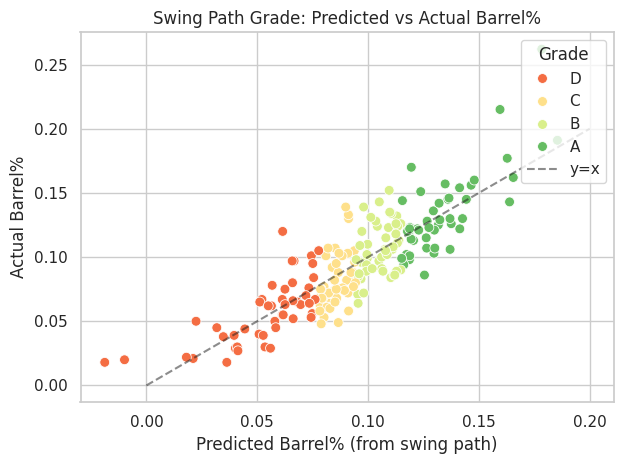

In [40]:
# Predicted vs actual Barrel% (colored by grade: A=best swing path, D=worst)
ax = sns.scatterplot(data=valid, x='pred_Barrel%', y='Barrel%', hue='grade', hue_order=['D','C','B','A'], palette='RdYlGn', s=50)
ax.plot([0, 0.2], [0, 0.2], 'k--', alpha=0.5, label='y=x')
ax.set_xlabel('Predicted Barrel% (from swing path)')
ax.set_ylabel('Actual Barrel%')
ax.set_title('Swing Path Grade: Predicted vs Actual Barrel%')
ax.legend(title='Grade', loc='upper right')
plt.tight_layout()
plt.show()

## Scatter Plots (vs Barrel%)

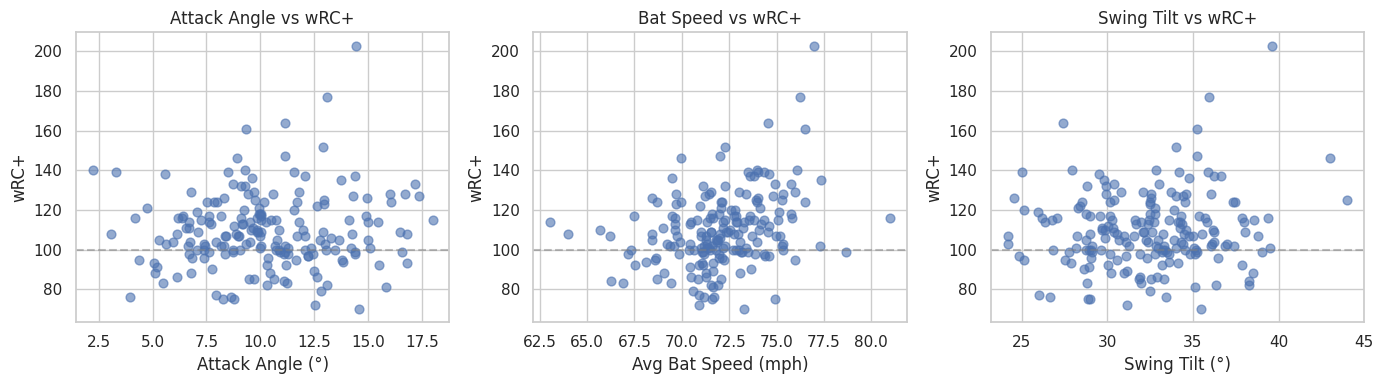

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Attack angle vs Barrel%
axes[0].scatter(df['attack_angle'], df['Barrel%'], alpha=0.6, s=40)
axes[0].set_xlabel('Attack Angle (°)')
axes[0].set_ylabel('Barrel%')
axes[0].set_title('Attack Angle vs Barrel%')

# Bat speed vs Barrel%
axes[1].scatter(df['avg_bat_speed'], df['Barrel%'], alpha=0.6, s=40)
axes[1].set_xlabel('Avg Bat Speed (mph)')
axes[1].set_ylabel('Barrel%')
axes[1].set_title('Bat Speed vs Barrel%')

# Swing tilt vs Barrel%
axes[2].scatter(df['swing_tilt'], df['Barrel%'], alpha=0.6, s=40)
axes[2].set_xlabel('Swing Tilt (°)')
axes[2].set_ylabel('Barrel%')
axes[2].set_title('Swing Tilt vs Barrel%')

plt.tight_layout()
plt.show()

## Top performers by Barrel% (labels)

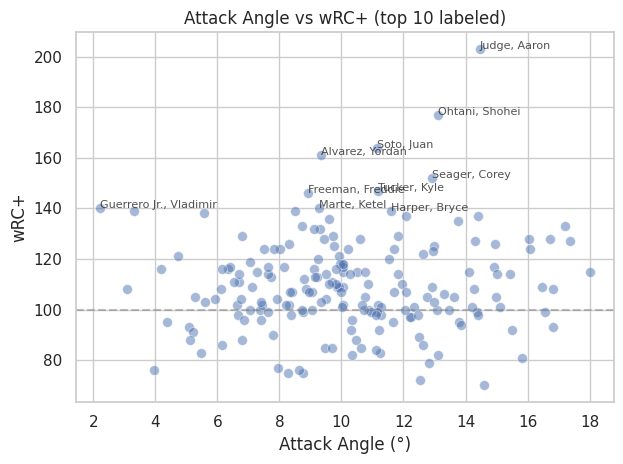

In [42]:
top = df.nlargest(10, 'Barrel%')[['name', 'attack_angle', 'avg_bat_speed', 'Barrel%']]
ax = sns.scatterplot(data=df, x='attack_angle', y='Barrel%', alpha=0.5, s=50)
for _, row in top.iterrows():
    ax.annotate(row['name'], (row['attack_angle'], row['Barrel%']), fontsize=8, alpha=0.8)
ax.set_xlabel('Attack Angle (°)')
ax.set_ylabel('Barrel%')
ax.set_title('Attack Angle vs Barrel% (top 10 labeled)')
plt.tight_layout()
plt.show()

## Key Takeaways

1. **Bat speed** has the strongest correlation with Barrel% — faster swings lead to more barrels.
2. **Swing tilt** and **attack angle** also correlate with Barrel%.
3. Swing path explains ~73% of Barrel% variance (R²) vs ~15% for outcomes like wRC+.
4. Grade = swing path quality; residual = over/underperformer vs prediction.
5. These are associations, not causation — pitch selection and contact point matter too.